In [1]:
from pathlib import Path
import os
import natsort
import mne

import seaborn as sns
import matplotlib.pyplot as plt

mne.set_log_level("CRITICAL")

sns.set()

In [2]:

def load_evoked(dataset_name):
    base = Path("../Dataset") / "evoked" / dataset_name

    files = natsort.natsorted(os.listdir(base))

    left_hand = [f for f in files if "left_hand" in f]
    right_hand = [f for f in files if "right_hand" in f]

    left_hand_evokeds_list = []
    for f in left_hand:
        evoked_left = mne.read_evokeds(base / f)
        if "EOG1" in evoked_left[0].ch_names:
            left_hand_evokeds_list.append(evoked_left[0])

    right_hand_evokeds_list = []
    for f in right_hand:
        evoked_right = mne.read_evokeds(base / f)
        if "EOG1" in evoked_right[0].ch_names:
            right_hand_evokeds_list.append(evoked_right[0])

    left_hand_evoked = mne.combine_evoked(left_hand_evokeds_list, weights="equal")
    right_hand_evoked = mne.combine_evoked(right_hand_evokeds_list, weights="equal")

    return left_hand_evoked, right_hand_evoked


def load_signed_r2(dataset_name):
    base = Path("../Dataset") / "signed_r2" / dataset_name

    files = natsort.natsorted(os.listdir(base))

    files_load = [f for f in files if "signed_r2-ave" in f]

    signed_r2_list = []
    for file in files_load:
        e = mne.read_evokeds(base / file)[0]
        signed_r2_list.append(e)
    signed_r2 = mne.combine_evoked(signed_r2_list, weights="equal")

    return signed_r2



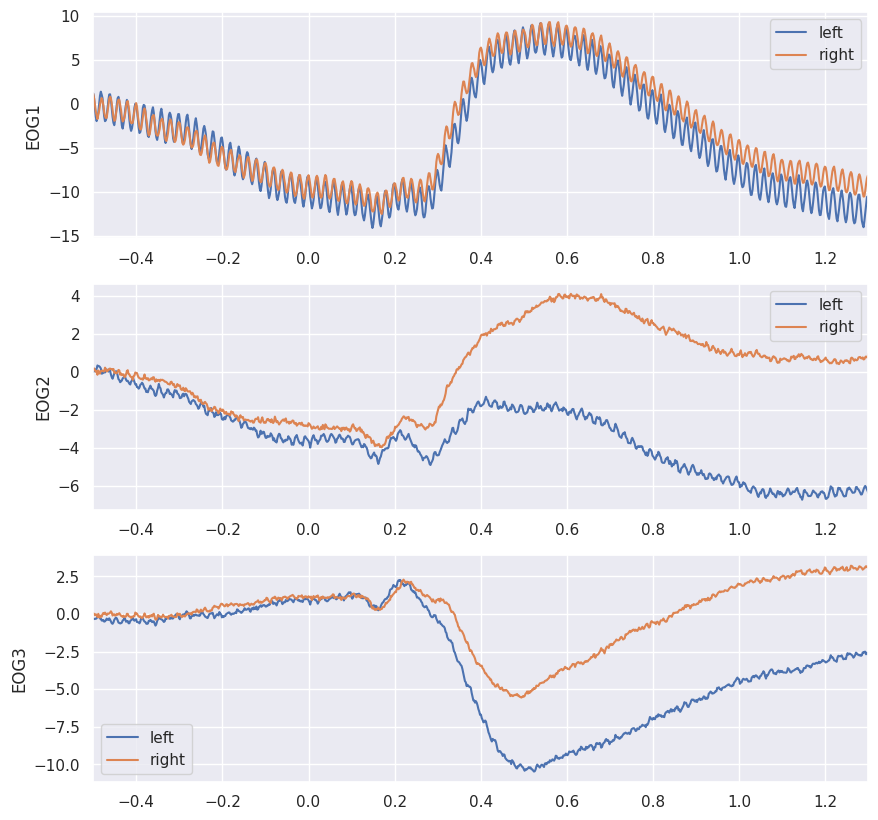

In [3]:

dataset_name = "Dreyer2023"

left_hand_evoked, right_hand_evoked = load_evoked(dataset_name)

left_hand_evoked.pick(picks="eog")
right_hand_evoked.pick(picks="eog")

left_hand_evoked.crop(tmin=-0.5, tmax=1.3)
right_hand_evoked.crop(tmin=-0.5, tmax=1.3)

signed_r2 = load_signed_r2(dataset_name)
signed_r2.crop(tmin=-0.5, tmax=1.3)

fig, ax = plt.subplots(3, 1, figsize=(10, 10))

ax[0].set_ylabel("EOG1")
sns.lineplot(x=left_hand_evoked.times, y=left_hand_evoked.get_data(picks="EOG1", units="uV").squeeze(), ax=ax[0],
             label="left")
sns.lineplot(x=right_hand_evoked.times, y=right_hand_evoked.get_data(picks="EOG1", units="uV").squeeze(), ax=ax[0],
             label="right")

ax[1].set_ylabel("EOG2")
sns.lineplot(x=left_hand_evoked.times, y=left_hand_evoked.get_data(picks="EOG2", units="uV").squeeze(), ax=ax[1],
             label="left")
sns.lineplot(x=right_hand_evoked.times, y=right_hand_evoked.get_data(picks="EOG2", units="uV").squeeze(), ax=ax[1],
             label="right")

ax[2].set_ylabel("EOG3")
sns.lineplot(x=left_hand_evoked.times, y=left_hand_evoked.get_data(picks="EOG3", units="uV").squeeze(), ax=ax[2],
             label="left")
sns.lineplot(x=right_hand_evoked.times, y=right_hand_evoked.get_data(picks="EOG3", units="uV").squeeze(), ax=ax[2],
             label="right")

for a in ax:
    a.set_xlim([-0.5, 1.3])

if dataset_name == "Dreyer2023":
    vlim = [-7.5, 7.5]
elif dataset_name == "Lee2019_MI":
    #vlim = [-7.5, 7.5]
    vlim = [-16, 16]